In [1]:
import os
import sys
from pathlib import Path
os.chdir('/zhome/71/c/146676/texture_tomography')
import h5py
import numpy as np
from pathlib import Path
from package.texture_tomography.operators.pfo_single_material import PFO_SINGLE, estimate_L_power
import yaml
from package.texture_tomography.optimization.fista_opencl import FISTAOpenCL
from package.texture_tomography.optimization.fista_huber_opencl import FISTAHuberOpenCL
from package.texture_tomography.gpu_live_tracker import GPUMemoryLogger
import pyopencl.array as clarray
from package.texture_tomography.multiresolution_refiner import OrientationTree
from package.texture_tomography.material import Material
import matplotlib.pyplot as plt
from orix import plot, sampling
from orix.crystal_map import Phase
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d
from scipy.spatial.transform import Rotation as R
from sklearn.neighbors import KDTree
import hdf5plugin
from numpy.typing import NDArray


INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.


Saving results to: /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/simulations/textomo_simulation_run_024


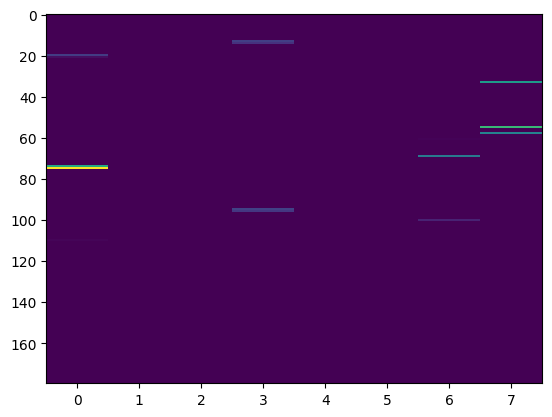

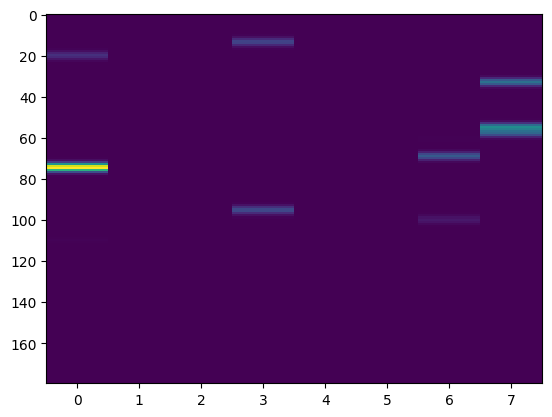

In [49]:

# ---------------------------
# CREATE RUN FOLDER
# ---------------------------
base_run_dir = Path("/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/simulations")

existing = sorted([p for p in base_run_dir.glob("textomo_simulation_run_*") if p.is_dir()])
if len(existing) == 0:
    run_id = 0
else:
    run_id = max(int(p.name.split("_")[-1]) for p in existing) + 1

run_dir = base_run_dir / f"textomo_simulation_run_{run_id:03d}"
run_dir.mkdir(parents=True, exist_ok=False)

print("Saving results to:", run_dir)

# ---------------------------
# CONFIG
# ---------------------------
config_path = "simulations/sim01.yaml"

with open(config_path, "r") as f:
    cfg = yaml.safe_load(f)

N_chi = cfg['N_chi']
N_rot = cfg['N_rot']
N_theta = cfg['N_theta']
Nx = cfg['Nx']
Ny = cfg['Ny']
datapath = cfg["datapath"]
cif_path = cfg["cif_path"]
cor_offset = cfg["cor_offset"]
wavelength_kev = cfg['wavelength']
min_two_theta = cfg['min_two_theta']
max_two_theta = cfg['max_two_theta']
reflection_cutoff = cfg['reflection_cutoff']

scan_name = 'polycrystal20grains' # 'polycrystal20grains', 'highly_deformed', 'very_highly_deformed'
filename = datapath + f'/{scan_name}_integrated_data.h5'

# ---------------------------
# LOAD DATA
# ---------------------------
import h5py
import numpy as np

with h5py.File(filename, "r") as f:
    dset = f["data_array"]
    lattice_ds = f["lattice"]
    hkl_ds = f["hkl_list"]

    # Type narrowing for Pylance
    assert isinstance(dset, h5py.Dataset)
    assert isinstance(lattice_ds, h5py.Dataset)
    assert isinstance(hkl_ds, h5py.Dataset)

    arr = np.empty(dset.shape, dtype=dset.dtype)

    A_lattice = lattice_ds[...]
    hkl_list = hkl_ds[...]

    dset.read_direct(arr)

arr = arr.squeeze()
arr = arr/arr.sum(axis=(0,1,2), keepdims=True)*arr.sum()/500
plt.imshow(arr[45,45],aspect='auto', interpolation='nearest')
plt.show()
from scipy.ndimage import gaussian_filter1d
arr = gaussian_filter1d(arr, sigma=1.3, axis=2)
plt.imshow(arr[45,45],aspect='auto', interpolation='nearest')
plt.show()

In [50]:
# ---------------------------
# MATERIAL
# ---------------------------
cif_folder = Path(cif_path)
filenames = [p.name for p in cif_folder.glob("*.cif")]
path = cif_folder / filenames[0]

mat = Material.from_lattice_parameters(
    lattice_matrix=A_lattice,                  # shape (3,3), 1/Å (crystallographic)
    lattice_matrix_kind="direct",
    symmetry_group="cubic",
    wavelength_kev=80.0,
    min_two_theta=0.0,                        # ignored when hkl_list is set
    max_two_theta=0.0,                        # ignored when hkl_list is set
    hkl_list=hkl_list,
)

print(2*np.pi/mat.reflections['d_spacing'])

[2.68757469 3.10334394 4.38879109 5.14631372 5.37514938 6.20668788
 6.76358131 6.93928801]


In [51]:

# ---------------------------
# GRID
# ---------------------------
# with h5py.File("/work3/msaca/basis_set.h5", "r") as f:
#     numpy_orien = f["numpy_orien"][...]
#     scores = f["scores"][...]

# grid = OrientationTree.from_rotation_matrices(numpy_orien, sigma=0.02)
grid_resolution_parameter = 20      # example
kernel_sigma = 0.10               # example
sigma_levels = [kernel_sigma]      # start with single level


R_random = R.random(15000).as_matrix() 


def prune_rotations(
    Rmats: NDArray[np.floating],  # shape (N, 3, 3)
    theta_deg: float,
    target: int = 5000,
    ) -> NDArray[np.floating]:
    # Convert to quaternions
    q = R.from_matrix(Rmats).as_quat(canonical=False)  # (x,y,z,w)
    q /= np.linalg.norm(q, axis=1, keepdims=True)

    # Antipodal equivalence: q and -q represent same rotation
    q_full = np.vstack([q, -q])

    tree = KDTree(q_full)

    theta = np.deg2rad(theta_deg)

    used = np.zeros(len(q_full), dtype=bool)
    keep = []

    for i in range(len(q)):
        if used[i]:
            continue

        keep.append(i)

        # mark neighbors as used
        idx = tree.query_radius(q[i:i+1], r=theta)[0]
        used[idx] = True

        if len(keep) >= target:
            break

    return Rmats[keep]


pruned_orient = prune_rotations(R_random, theta_deg=0.5, target=15000)

sigma = 0.04
grid = OrientationTree.from_rotation_matrices(pruned_orient, sigma)#.transpose((0,2,1)), sigma=sigma)
print('Generated grid')

Generated grid


# SET THE CORRECT OMEGA, AND THE 5 AXES

In [52]:

# ---------------------------
# OPERATOR
# ---------------------------
op = PFO_SINGLE(cfg=cfg, material=mat, grid=grid, max_gb=1.0,
                verbose=True, normalized=True)

gpu_log = GPUMemoryLogger(interval=0.5, gpu_id=2)
gpu_log.start()

queue = op.queue
Nx, Ny, K = op.Nx, op.Ny, op.K

x_gpu = clarray.zeros(queue, (Nx, Ny, K), dtype=np.float32, order="F")

out_cpu = np.ascontiguousarray(arr.reshape(N_rot, Nx, N_chi*N_theta), dtype=np.float32)
out_gpu = clarray.to_device(queue, out_cpu)

# ---------------------------
# SOLVE
# ---------------------------
norm_sq = estimate_L_power(op, niter=10, seed=0, eps=1e-30, verbose=1)

solver = FISTAOpenCL(op, prox_kind="nonneg", lam=2.5e5, L=1.1*norm_sq)
solver.run(x_gpu, out_gpu, niter=40, verbose=1, diagnostics_interval=1)


prediction = op.direct(x_gpu)
prediction_cpu = prediction.get().reshape((N_rot, Nx, N_chi, N_theta))


coeffs = x_gpu.get().transpose((0,1,2))[::-1,::-1]

0.3542285714285714
[0.15166333 0.17518185 0.24806343 0.29116228 0.30420768 0.35172608
 0.3836607  0.39375663]

=== OpenCL buffer allocation summary ===
coeffs_sino_F                 : shape=(103x90x2071),    73.24 MB
coeffs_sino_C                 : shape=(90x103x2071),    73.24 MB
_coeffs_batch_F               : shape=(103x103x2071),    83.81 MB
_basis_batch_kmax             : shape=(90x2071x180x8),  1023.87 MB
_basis_batch_transpose_kmax   : shape=(90x1440x2071),  1023.87 MB
_grid_inv_kmax                : shape=(2071x9),     0.07 MB
_inv_sigma2_kmax              : shape=(2071),     0.01 MB
_norm_factor_kmax             : shape=(2071),     0.01 MB
---------------------------------------
TOTAL GPU buffer memory:  2278.11 MB

[power 01] L_est=4.594170e+06  ||z||=8.004469e+07
[power 02] L_est=1.838255e+10  ||z||=3.992993e+10
[power 03] L_est=1.451075e+11  ||z||=1.552750e+11
[power 04] L_est=1.721546e+11  ||z||=1.730193e+11
[power 05] L_est=1.744212e+11  ||z||=1.745078e+11
[power 06] L_es

All outputs saved in: /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/simulations/textomo_simulation_run_024


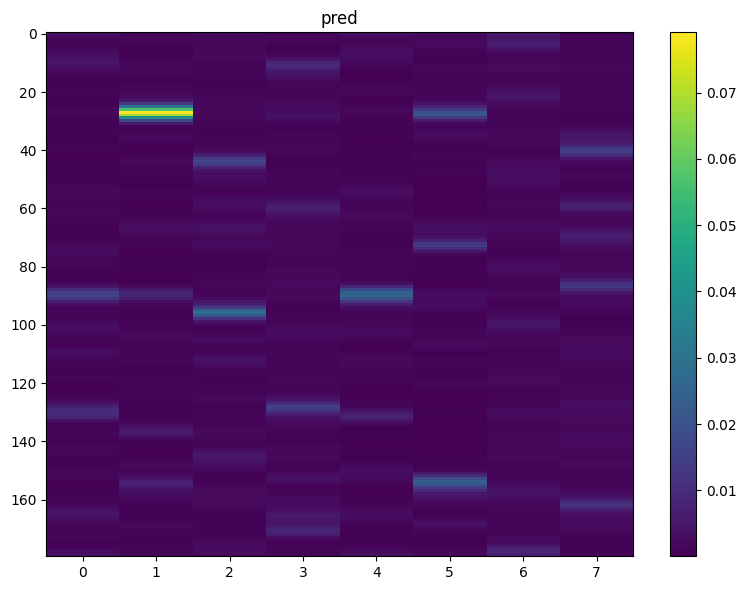

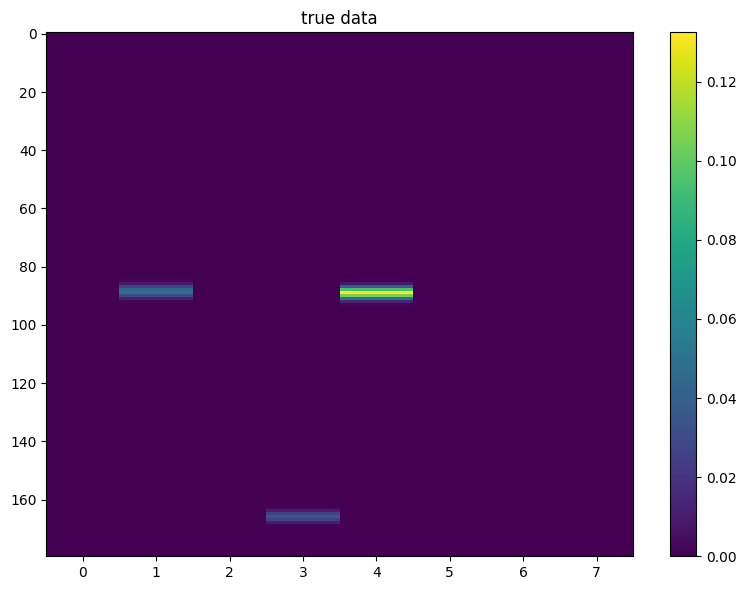

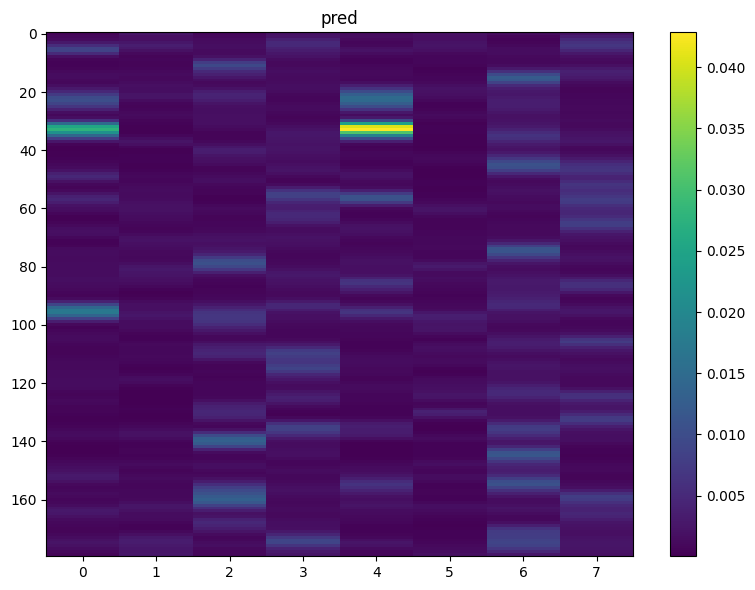

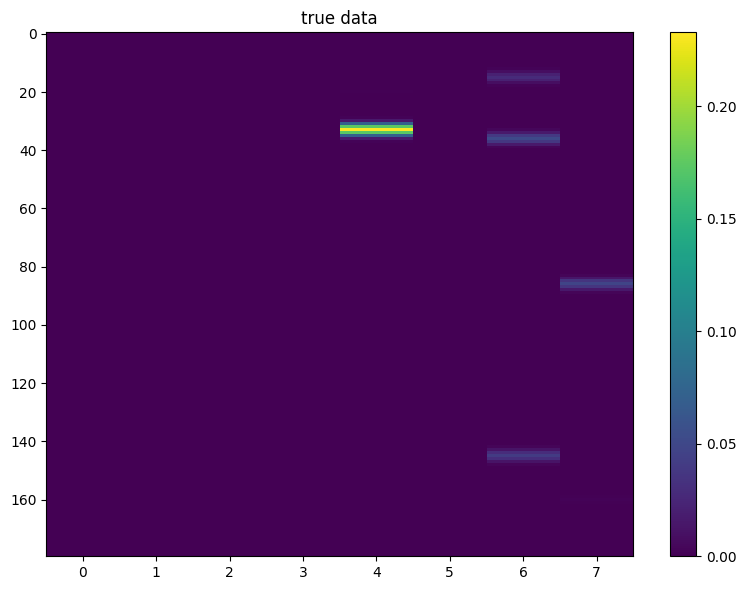

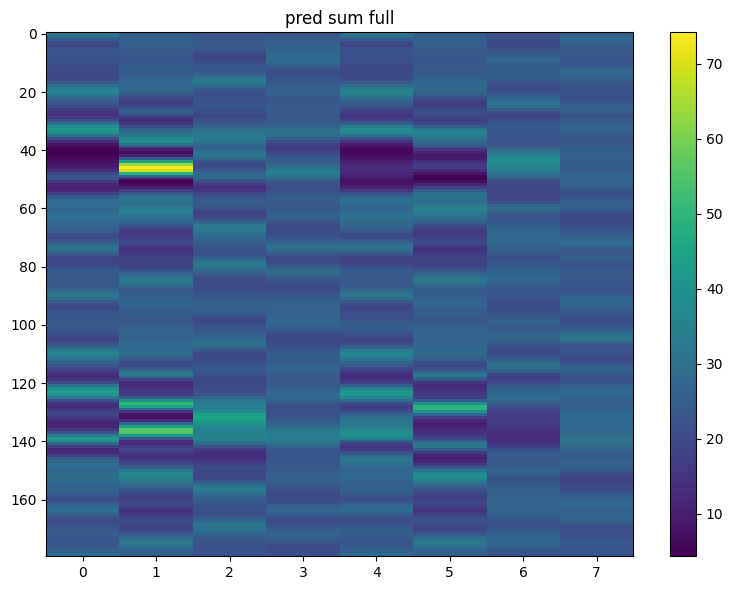

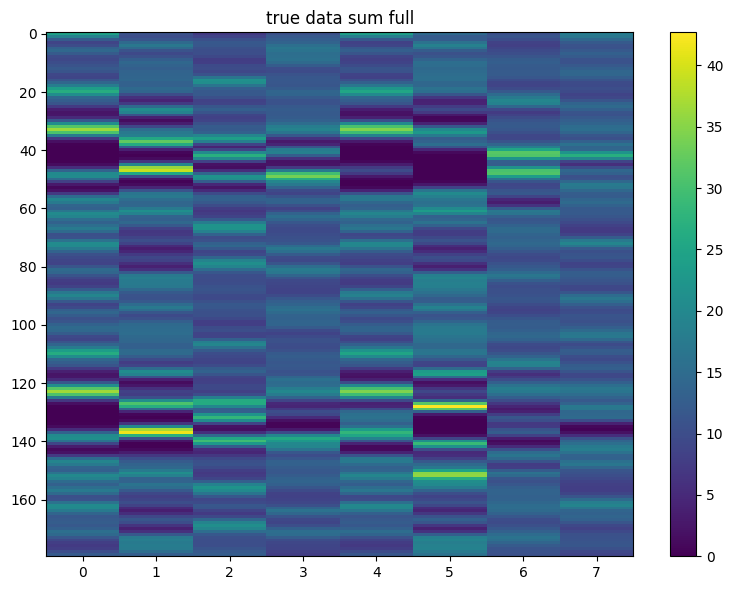

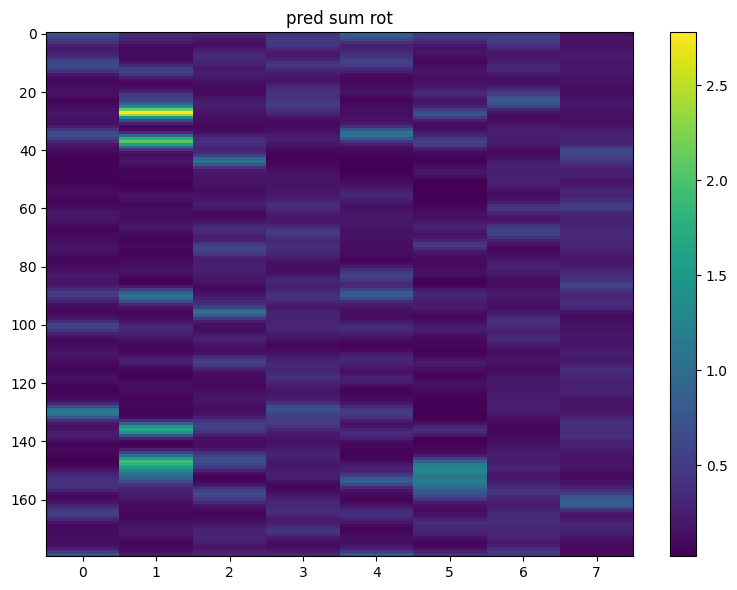

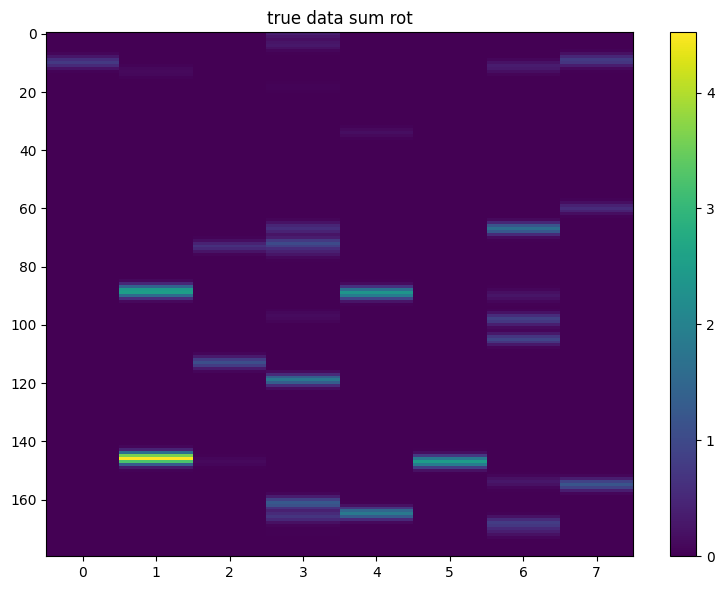

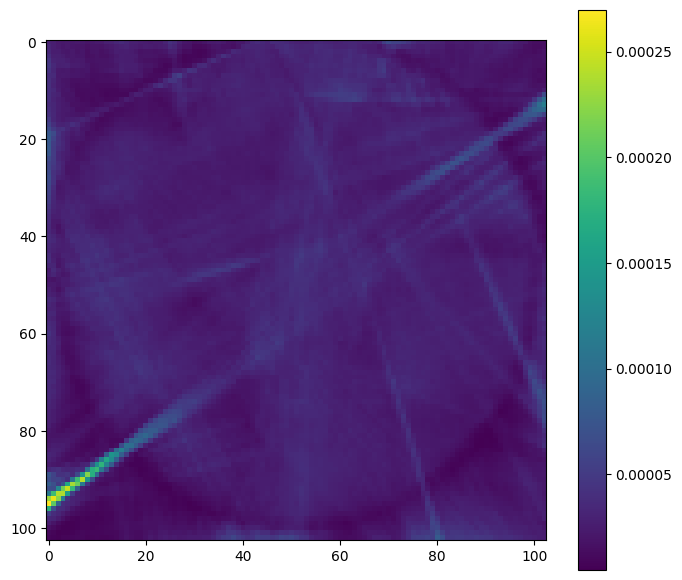

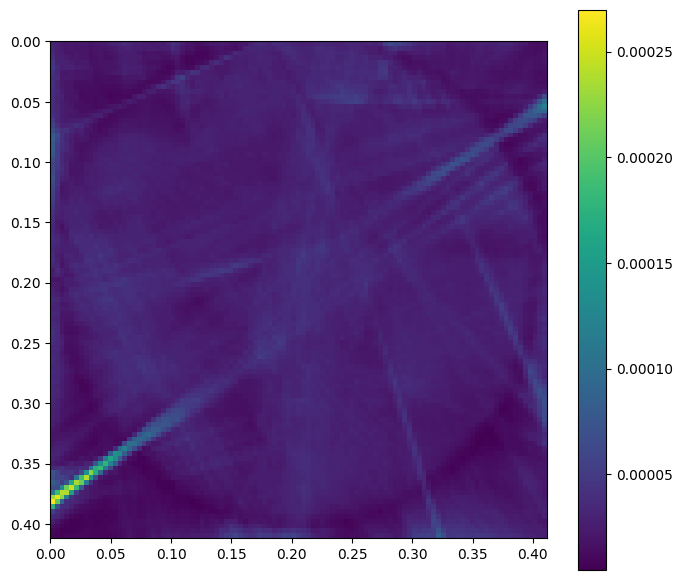

In [54]:

# ---------------------------
# SAVE RECONSTRUCTION
# ---------------------------
reconstruction_path = run_dir / "reconstruction.h5"
with h5py.File(reconstruction_path, "w") as f:
    f.create_dataset("x", data=coeffs, compression=None)
    f.create_dataset("y", data=prediction_cpu, compression=None)

# ---------------------------
# PLOTS
# ---------------------------

plt.figure(figsize=(8,6))
plt.imshow(prediction_cpu[0,90], aspect='auto', interpolation='nearest')
plt.title('pred')
plt.colorbar()
plt.tight_layout()
#plt.savefig(run_dir/"prediction_00.png", dpi=300)

plt.figure(figsize=(8,6))
plt.imshow(arr[0,90], aspect='auto', interpolation='nearest')
plt.title('true data')
plt.colorbar()
plt.tight_layout()
#plt.savefig(run_dir/"measured_00.png", dpi=300)

plt.figure(figsize=(8,6))
plt.imshow(prediction_cpu[40,70], aspect='auto', interpolation='nearest')
plt.title('pred')
plt.colorbar()
plt.tight_layout()
#plt.savefig(run_dir/"prediction_01.png", dpi=300)

plt.figure(figsize=(8,6))
plt.imshow(arr[40,70], aspect='auto', interpolation='nearest')
plt.title('true data')
plt.colorbar()
plt.tight_layout()
#plt.savefig(run_dir/"measured_01.png", dpi=300)

plt.figure(figsize=(8,6))
plt.imshow(prediction_cpu[:,:].sum(axis=(0,1)), aspect='auto', interpolation='nearest')
plt.title('pred sum full')
plt.colorbar()
plt.tight_layout()
#plt.savefig(run_dir/"prediction_sum_00.png", dpi=300)


plt.figure(figsize=(8,6))
plt.imshow(arr[:,:].sum(axis=(0,1)), aspect='auto', interpolation='nearest')
plt.colorbar()
plt.title('true data sum full')
plt.tight_layout()
plt.savefig(run_dir/"measured_sum_00.png", dpi=300)

plt.figure(figsize=(8,6))
plt.imshow(prediction_cpu[0,:].sum(axis=(0)), aspect='auto', interpolation='nearest')
plt.title('pred sum rot')
plt.colorbar()
plt.tight_layout()
#plt.savefig(run_dir/"prediction_sumtrans_00.png", dpi=300)


plt.figure(figsize=(8,6))
plt.imshow(arr[0,:].sum(axis=(0)), aspect='auto', interpolation='nearest')
plt.title('true data sum rot')
plt.colorbar()
plt.tight_layout()
#plt.savefig(run_dir/"measured_sumtrans_00.png", dpi=300)


plt.figure(figsize=(7,6))
plt.imshow(coeffs.sum(axis=-1))
plt.colorbar()
plt.tight_layout()
#plt.savefig(run_dir/"coeff_sum.png", dpi=300)


grid_sp = R.concatenate(grid.rotations_at_level(0))

stepsize = 0.004
imshow_opts = {'extent':(0, coeffs.shape[0]*stepsize, coeffs.shape[1]*stepsize, 0)}

plt.figure(figsize=(7,6))
plt.imshow(coeffs.sum(axis=2), **imshow_opts)
plt.colorbar()
plt.tight_layout()
#plt.savefig(run_dir/"coeff_sum_spatial.png", dpi=300)


sums = coeffs.sum(axis=-1)
cutoff = np.quantile(sums,0.1)

def save_ipf(direction, name):
    ipfkey = plot.IPFColorKeyTSL(symmetry.Oh, direction=Vector3d(direction))
    orientations = Orientation.from_scipy_rotation(grid_sp)
    orientations.symmetry = ipfkey.symmetry
    rgb = ipfkey.orientation2color(orientations)[np.argmax(coeffs, axis=-1)]
    mask = coeffs.sum(axis=2)>cutoff
    rgb[~mask] *= 0

    plt.figure(figsize=(7,6))
    plt.imshow(rgb[::-1, ::-1], **imshow_opts)
    plt.tight_layout()
    #plt.savefig(run_dir/name, dpi=300)
    plt.close()

save_ipf([1,0,0], "ipf_x.png")
save_ipf([0,1,0], "ipf_y.png")
save_ipf([0,0,1], "ipf_z.png")

print("All outputs saved in:", run_dir)


In [ ]:
# Do a test with the actual orientations used...